In [1]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Churn Data
file_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    import requests
    from io import StringIO
    url = "https://raw.githubusercontent.com/selva86/datasets/master/Customer-Churn.csv"
    response = requests.get(url)
    data = StringIO(response.text)
    df = pd.read_csv(data)
    df.to_csv(file_path, index=False)

# Clean
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# Separate X and y
y = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(['Churn', 'customerID'], axis=1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data ready! Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Data ready! Train: 5625, Test: 1407


In [7]:
# Identify columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_cols)
    ])

In [12]:
# 1. Logistic Regression (Baseline)
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 2. Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 3. XGBoost
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss'))
])
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("All models trained!")

All models trained!


In [13]:
# Create comparison table
models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

results = []
for name, pred in models.items():
    acc = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(report['macro avg']['precision'], 4),
        'Recall': round(report['macro avg']['recall'], 4),
        'F1-Score': round(report['macro avg']['f1-score'], 4)
    })

comparison_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON ===")
print(comparison_df.to_string(index=False))


=== MODEL COMPARISON ===
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7313     0.7002  0.7505    0.7027
      Random Forest    0.7839     0.7253  0.6780    0.6933
            XGBoost    0.7740     0.7081  0.6857    0.6947


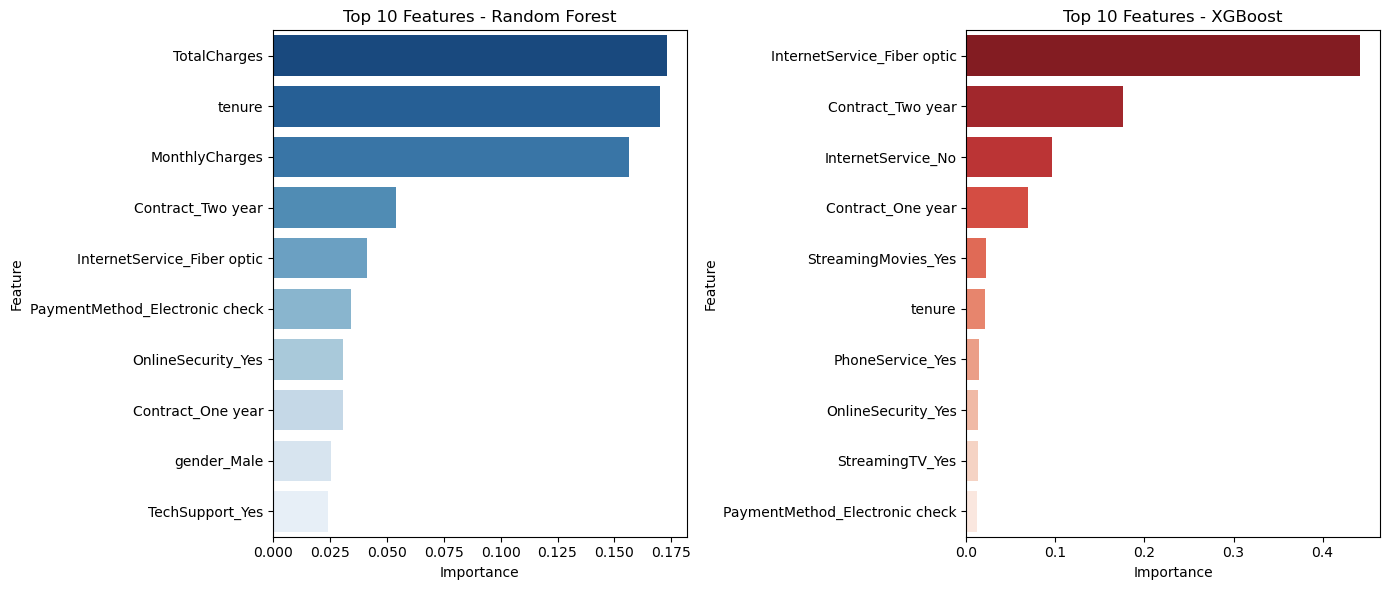

In [14]:
# Get feature names after preprocessing
preprocessor.fit(X_train)
feature_names = (numerical_cols + 
                 list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)))

# Random Forest Importances
rf_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.named_steps['classifier'].feature_importances_
}).sort_values('Importance', ascending=False).head(10)

# XGBoost Importances
xgb_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.named_steps['classifier'].feature_importances_
}).sort_values('Importance', ascending=False).head(10)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=rf_imp, x='Importance', y='Feature', ax=axes[0], palette='Blues_r', hue='Feature', legend=False)
axes[0].set_title('Top 10 Features - Random Forest')

sns.barplot(data=xgb_imp, x='Importance', y='Feature', ax=axes[1], palette='Reds_r', hue='Feature', legend=False)
axes[1].set_title('Top 10 Features - XGBoost')

plt.tight_layout()
plt.show()

 How Random Forest and XGBoost Differ

Random Forest builds many decision trees in parallel, each trained on a random sample of the data and random subset of features. All trees have equal voting power, and the final prediction is the average (or majority vote) of all trees. This approach reduces overfitting and variance.
XGBoost builds trees sequentially, where each new tree corrects errors made by previous trees. Trees are weighted based on their performance, and the model focuses on misclassified data points. This sequential approach reduces bias and often achieves higher accuracy, but is more prone to overfitting.

Key Difference: Random Forest = parallel bagging (independent trees), XGBoost = sequential boosting (trees learn from each other's mistakes).